In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -U scikit-posthocs

In [3]:
pip install ucimlrepo

In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/RecPad')

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils.plot_dashes as plot_dashes
import scikit_posthocs as sp
import time

from collections import Counter
from ucimlrepo import fetch_ucirepo 
from scipy.stats import friedmanchisquare
from conf.processing import DataProcessing
from utils import genetic_algorithm as gen_alg
from models import adaline, ann_models, k_near, kernel_method, tree_based_ensemble as tree_based

pd.set_option('display.float_format', '{:.6f}'.format)

Dataset

In [ ]:

all_results = []
all_runs = []
ga_runs = []

def get_datasets():

    # Arquivos locais
    file_path = '/content/drive/MyDrive/Colab Notebooks/RecPad/data'

    for file_name in os.listdir(file_path):

        full_path = os.path.join(file_path, file_name)

        yield {
            'name': file_name,
            'data': pd.read_csv(full_path, sep='\t', decimal='.')
        }

    # Air Quality

    air_quality = fetch_ucirepo(id=360)

    umidade = (
        air_quality.data.features[['RH']]
        .replace(-200, np.nan)
        .dropna()
        .iloc[:3000]
        .reset_index(drop=True)
    )

    yield {
        'name': 'air_quality_rh',
        'data': umidade
    }

    # Appliances Energy

    appliances = fetch_ucirepo(id=374)

    consumo = (
        appliances.data.targets[['Appliances']]
        .iloc[:3000]
    )

    yield {
        'name': 'appliances_energy',
        'data': consumo.reset_index(drop=True)
    }

In [ ]:
for dataset in get_datasets():

    dataset_name = dataset['name']
    dataset_data = dataset['data']

    raw_data = DataProcessing(dataset_data, n_lags=5)
    prep_data = raw_data.prepare_data()

    mlp = ann_models.MLP()
    inicio = time.time()
    results_MLP = mlp.train(prep_data)
    print(f"Dataset: {dataset_name}, MLP: {(time.time()-inicio):.2f} s")
    MLP_forecast_v = np.array(results_MLP['pred_valid'])
    MLP_forecast = np.array(results_MLP['pred_test_denom'])
    
    scn = ann_models.GridSCN()
    inicio = time.time()
    results_SCN = scn.train(prep_data)
    print(f"Dataset: {dataset_name}, SCN: {(time.time()-inicio):.2f} s")
    SCN_forecast_v = np.array(results_SCN['pred_valid'])
    SCN_forecast = np.array(results_SCN['pred_test'])

    elm = ann_models.GridELM()
    inicio = time.time()
    results_ELM = elm.train(prep_data)
    print(f"Dataset: {dataset_name}, ELM: {(time.time()-inicio):.2f} s")
    ELM_forecast_v = np.array(results_ELM['pred_valid'])
    ELM_forecast = np.array(results_ELM['pred_test_denom'])

    svr = kernel_method.SVM()
    inicio = time.time()
    results_SVR = svr.train(prep_data)
    print(f"Dataset: {dataset_name}, SVR: {(time.time()-inicio):.2f} s")
    SVR_forecast_v = np.array(results_SVR['pred_valid'])
    SVR_forecast = np.array(results_SVR['pred_test'])
    
    # rf = tree_based.RF()
    # results_RF = rf.train(prep_data)
    # RF_forecast_v = np.array(results_RF['pred_valid'])
    # RF_forecast = np.array(results_RF['pred_test'])

    # gb = tree_based.GBoosting()
    # results_GB = gb.train(prep_data)
    # GB_forecast_v = np.array(results_GB['pred_valid'])
    # GB_forecast = np.array(results_GB['pred_test'])

    ada = adaline.Adaline()
    inicio = time.time()
    results_ADA = ada.train(prep_data)
    print(f"Dataset: {dataset_name}, ADA: {(time.time()-inicio):.2f} s")
    ADA_forecast_v = np.array(results_ADA['pred_valid'])
    ADA_forecast = np.array(results_ADA['pred_test_denom'])

    KNN = k_near.KNEAR()
    inicio = time.time()
    results_KNN = KNN.train(prep_data)
    print(f"Dataset: {dataset_name}, KNN: {(time.time()-inicio):.2f} s")
    KNN_forecast_v = np.array(results_KNN['pred_valid'])
    KNN_forecast = np.array(results_KNN['pred_test_denom'])

    forecast_valid = {
        "MLP": MLP_forecast_v,
        "ELM": ELM_forecast_v,
        "SCN": SCN_forecast_v,
        "SVR": SVR_forecast_v,
        "ADA": ADA_forecast_v,
        "KNN": KNN_forecast_v
    }

    forecast_test = {
        "MLP": MLP_forecast,
        "ELM": ELM_forecast,
        "SCN": SCN_forecast,
        "SVR": SVR_forecast,
        "ADA": ADA_forecast,
        "KNN": KNN_forecast
    }

    ranking = {
        "MLP": results_MLP['best_error'],
        "ELM": results_ELM['best_error'],
        "SCN": results_SCN['best_error'],
        "SVR": results_SVR['best_error'],
        "KNN": results_KNN['best_error'],
        "ADA": results_ADA['best_error'],
    }

    ranking = sorted(
        ranking.items(),
        key=lambda x: x[1]
    )

    selected_models = [model for model, _ in ranking[:4]]

    P_v = np.column_stack(
        [forecast_valid[m] for m in selected_models]
    )

    P = np.column_stack(
        [forecast_test[m] for m in selected_models]
    )


    for x in range(30):
        
        ga = gen_alg.GeneticAlgorithm()
        
        ga_result = ga.execute(P_v, prep_data['target_valid'])

        y_hat = P @ ga_result['best_ind']
        ga_metrics = plot_dashes.get_metrics_error(prep_data['target_test'], y_hat)

        ga_runs.append({

            'Dataset': dataset_name,
            'Run': x,
            'Selected_Models': selected_models,

            'MSE': ga_metrics['MSE'],
            'RMSE': ga_metrics['RMSE'],
            'MAE': ga_metrics['MAE'],
            'MAPE': ga_metrics['MAPE'],

            'Weights': ga_result['best_ind'],
            'Fitness': ga_result['best_fitness'],
            'Fitness_Curve': ga_result['fitness_curve']

        })

    ga_dataset = [ run for run in ga_runs if run["Dataset"] == dataset_name ]

    best = max( 
        ga_dataset,
        key=lambda r: r["Fitness"]
    )

    y_hat_final = P @ best["Weights"]

    weights = np.array([1/4]*4)
    ensemble_mean = P @ weights

    MLP = plot_dashes.get_metrics_error(prep_data['target_test'], MLP_forecast)
    SCN = plot_dashes.get_metrics_error(prep_data['target_test'], SCN_forecast)
    ELM = plot_dashes.get_metrics_error(prep_data['target_test'], ELM_forecast)
    SVR = plot_dashes.get_metrics_error(prep_data['target_test'], SVR_forecast)
    ADA = plot_dashes.get_metrics_error(prep_data['target_test'], ADA_forecast)
    KNN = plot_dashes.get_metrics_error(prep_data['target_test'], KNN_forecast)
    EMEAN = plot_dashes.get_metrics_error(prep_data['target_test'], ensemble_mean)
    GA = plot_dashes.get_metrics_error(prep_data['target_test'], y_hat_final)

    all_results.append({
        'dataset': dataset_name,
        'MLP': MLP,
        'SCN': SCN,
        'ELM': ELM,
        'SVR': SVR,
        'ADA': ADA,
        'KNN': KNN,
        'EMEAN': EMEAN,
        'GA': GA
    })

    all_runs.append({
        'dataset': dataset_name,
        'model': 'MLP',
        'runs': results_MLP['lst_results']
    })

    all_runs.append({
        'dataset': dataset_name,
        'model': 'SCN',
        'runs': results_SCN['lst_results']
    })

    all_runs.append({
        'dataset': dataset_name,
        'model': 'ELM',
        'runs': results_ELM['lst_results']
    })

    all_runs.append({
        'dataset': dataset_name,
        'model': 'SVR',
        'runs': results_SVR['lst_results']
    })

    all_runs.append({
        'dataset': dataset_name,
        'model': 'ADA',
        'runs': results_ADA['lst_results']
    })

    all_runs.append({
        'dataset': dataset_name,
        'model': 'KNN',
        'runs': results_KNN['lst_results']
    })
    

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Dataset: airlines.txt, MLP: 22.17 s
Dataset: airlines.txt, SCN: 1.76 s
Dataset: airlines.txt, ELM: 1.04 s
Dataset: airlines.txt, SVR: 0.31 s
Dataset: airlines.txt, ADA: 4.47 s
Dataset: airlines.txt, KNN: 0.23 s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Dataset: lynx.txt, MLP: 21.24 s
Dataset: lynx.txt, SCN: 1.67 s
Dataset: lynx.txt, ELM: 0.34 s
Dataset: lynx.txt, SVR: 0.22 s
Dataset: lynx.txt, ADA: 4.93 s
Dataset: lynx.txt, KNN: 0.18 s
Dataset: coloradoRiver.txt, MLP: 37.58 s
Dataset: coloradoRiver.txt, SCN: 21.13 s
Dataset: coloradoRiver.txt, ELM: 0.56 s
Dataset: coloradoRiver.txt, SVR: 2.70 s
Dataset: coloradoRiver.txt, ADA: 28.04 s
Dataset: coloradoRiver.txt, KNN: 7.54 s
Dataset: melbmin.txt, MLP: 105.61 s


In [ ]:
df_results = pd.DataFrame(all_results)
df_runs = pd.DataFrame(all_runs)

In [ ]:
# 1. Tabela Principal (MSE, RMSE, MAE e MAPE)
rows = []

for _, row in df_results.iterrows():

    dataset = row['dataset']

    for model in ['MLP','SCN','ELM','SVR','ADA','KNN', 'EMEAN', 'GA']:
        metrics = row[model]
        rows.append({

            'Dataset': dataset,
            'Model': model,

            'MSE': metrics['MSE'],
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MAPE': metrics['MAPE']

        })

df_metrics = pd.DataFrame(rows)

In [ ]:
df_metrics

,Dataset,Model,MSE,RMSE,MAE,MAPE
0,airlines.txt,MLP,3677.685524,60.643924,46.947457,0.099546
1,airlines.txt,SCN,8963.457483,94.675538,71.972122,0.172427
2,airlines.txt,ELM,14018.358953,118.399151,91.213085,0.217716
3,airlines.txt,SVR,15222.424587,123.379190,105.387674,0.222434
4,airlines.txt,ADA,2171.837052,46.602973,38.857969,0.087360
5,airlines.txt,KNN,27837.968332,166.847141,149.147783,0.320394
6,airlines.txt,EMEAN,3076.131205,55.462881,45.623671,0.104944
7,airlines.txt,GA,3267.597447,57.162903,46.199098,0.108245
8,lynx.txt,MLP,553054.971571,743.676658,561.965866,0.748992
9,lynx.txt,SCN,652678.137599,807.884978,532.199909,1.287429


In [ ]:
# 2. Média das Métricas por Modelo
df_metrics.groupby('Model')[['MSE','RMSE','MAE','MAPE']].mean()

,MSE,RMSE,MAE,MAPE
Model,,,,
ADA,157166.665129,210.237830,160.396628,0.752747
ELM,145566.560592,218.747984,173.348245,0.520705
EMEAN,147716.291322,206.256303,146.976397,0.387340
GA,140093.648124,201.585298,139.620997,0.362818
KNN,287606.037821,307.537799,206.108739,0.574708
MLP,139184.519131,201.782364,152.773564,0.592510
SCN,165411.778228,226.360195,151.595688,0.710248
SVR,407780.949493,349.343362,264.713658,0.451048


In [ ]:
df_metrics.groupby("Model").agg({
    "MSE":["mean","std"],
    "RMSE":["mean","std"],
    "MAE":["mean","std"],
    "MAPE":["mean","std"]
})

MSE                     RMSE                   MAE             \
               mean           std       mean        std       mean        std   
Model                                                                           
ADA   157166.665129 312883.450622 210.237830 388.100880 160.396628 293.942416   
ELM   145566.560592 281861.410936 218.747984 360.954069 173.348245 287.677636   
EMEAN 147716.291322 293381.759574 206.256303 374.476753 146.976397 262.915077   
GA    140093.648124 278009.604718 201.585298 364.155673 139.620997 247.956192   
KNN   287606.037821 556802.944803 307.537799 507.315208 206.108739 318.669419   
MLP   139184.519131 275919.073591 201.782364 362.341269 152.773564 273.650606   
SCN   165411.778228 324871.702569 226.360195 390.167212 151.595688 255.926480   
SVR   407780.949493 805441.975522 349.343362 617.241352 264.713658 460.381937   

          MAPE           
          mean      std  
Model                    
ADA   0.752747 0.699024  
ELM   0.520705 0.524859  
EMEAN 0.387340 0.279038  
GA    0.362818 0.239518  
KNN   0.574708 0.455066  
MLP   0.592510 0.557363  
SCN   0.710248 0.600520  
SVR   0.451048 0.271589

In [ ]:
# 3. Ranking dos Modelos
ranking = []

for dataset in df_metrics['Dataset'].unique():

    temp = df_metrics[df_metrics['Dataset']==dataset]
    temp = temp.sort_values('MSE')
    temp['Rank'] = range(1,len(temp)+1)
    ranking.append(temp)

df_rank = pd.concat(ranking)

In [ ]:
df_rank

,Dataset,Model,MSE,RMSE,MAE,MAPE,Rank
4,airlines.txt,ADA,2171.837052,46.602973,38.857969,0.087360,1
6,airlines.txt,EMEAN,3076.131205,55.462881,45.623671,0.104944,2
7,airlines.txt,GA,3267.597447,57.162903,46.199098,0.108245,3
0,airlines.txt,MLP,3677.685524,60.643924,46.947457,0.099546,4
1,airlines.txt,SCN,8963.457483,94.675538,71.972122,0.172427,5
2,airlines.txt,ELM,14018.358953,118.399151,91.213085,0.217716,6
3,airlines.txt,SVR,15222.424587,123.379190,105.387674,0.222434,7
5,airlines.txt,KNN,27837.968332,166.847141,149.147783,0.320394,8
8,lynx.txt,MLP,553054.971571,743.676658,561.965866,0.748992,1
15,lynx.txt,GA,557101.664606,746.392433,510.181671,0.557491,2


In [ ]:
df_rank.groupby('Model')['Rank'].mean()

,Rank
Model,
ADA,4.500000
ELM,3.500000
EMEAN,3.750000
GA,2.000000
KNN,7.750000
MLP,3.250000
SCN,5.750000
SVR,5.500000


In [ ]:
# 4. Média e Desvio das Execuções - Valores NaN

rows=[]

for _,row in df_runs.iterrows():

    for i,mse in enumerate(row['runs']):

        rows.append({

            'Dataset':row['dataset'],
            'Model':row['model'],
            'Run':i,
            'MSE':mse

        })

df_runs_expand = pd.DataFrame(rows)

df_runs_expand.groupby(
    ['Dataset','Model']
)['MSE'].agg(
    ['mean','std','min','max']
)

mean           std            min  \
Dataset           Model                                               
airlines.txt      ADA      2171.837052           NaN    2171.837052   
                  ELM     15647.906514   1174.005151   14018.358953   
                  KNN     27837.968332           NaN   27837.968332   
                  MLP      4045.443629   1093.692864    3677.685524   
                  SCN      8963.457483           NaN    8963.457483   
                  SVR     15222.424587           NaN   15222.424587   
coloradoRiver.txt ADA         0.317598           NaN       0.317598   
                  ELM         0.263578      0.002166       0.262550   
                  KNN         1.948353           NaN       1.948353   
                  MLP         0.318504      0.029437       0.277628   
                  SCN         0.375189           NaN       0.375189   
                  SVR         0.315603           NaN       0.315603   
lynx.txt          ADA    626489.334807           NaN  626489.334807   
                  ELM    640352.751354 168182.828853  517941.771285   
                  KNN   1122578.521739           NaN 1122578.521739   
                  MLP    557553.219704  28530.463384  507075.470156   
                  SCN    652678.137599           NaN  652678.137599   
                  SVR   1615895.979524           NaN 1615895.979524   
melbmin.txt       ADA         5.171060           NaN       5.171060   
                  ELM         5.113779      0.002983       5.109173   
                  KNN         5.712861           NaN       5.712861   
                  MLP         5.100387      0.022292       5.079239   
                  SCN         5.142641           NaN       5.142641   
                  SVR         5.078260           NaN       5.078260   

                                   max  
Dataset           Model                 
airlines.txt      ADA      2171.837052  
                  ELM     16637.993495  
                  KNN     27837.968332  
                  MLP      7152.880000  
                  SCN      8963.457483  
                  SVR     15222.424587  
coloradoRiver.txt ADA         0.317598  
                  ELM         0.267687  
                  KNN         1.948353  
                  MLP         0.351731  
                  SCN         0.375189  
                  SVR         0.315603  
lynx.txt          ADA    626489.334807  
                  ELM   1097048.493472  
                  KNN   1122578.521739  
                  MLP    587937.584708  
                  SCN    652678.137599  
                  SVR   1615895.979524  
melbmin.txt       ADA         5.171060  
                  ELM         5.115625  
                  KNN         5.712861  
                  MLP         5.121536  
                  SCN         5.142641  
                  SVR         5.078260

In [ ]:
# 5. Organizar o GA

df_ga = pd.DataFrame(ga_runs)

In [ ]:
df_ga.groupby('Dataset')['MSE'].agg(
    ['mean', 'std', 'min', 'max']
)

,mean,std,min,max
Dataset,,,,
airlines.txt,3454.311641,126.128326,3267.597447,3763.396003
coloradoRiver.txt,0.316199,0.016465,0.289140,0.354130
lynx.txt,558886.726636,5509.204701,548724.304800,577363.776070
melbmin.txt,5.038686,0.002550,5.033059,5.048574


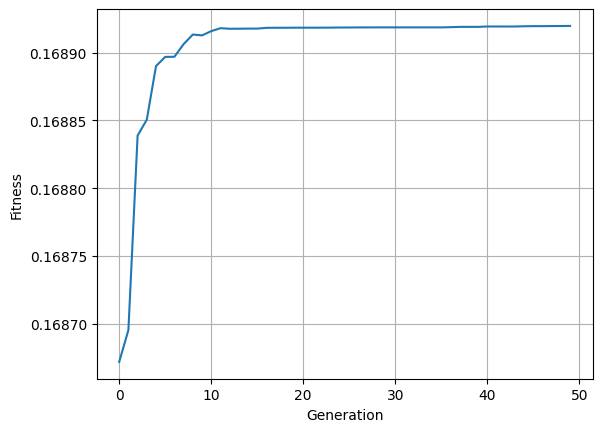

In [ ]:
# 7. Curva de Convergência

ga_result['fitness_curve']
plt.plot(ga_result['fitness_curve'])
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.grid()
plt.show()

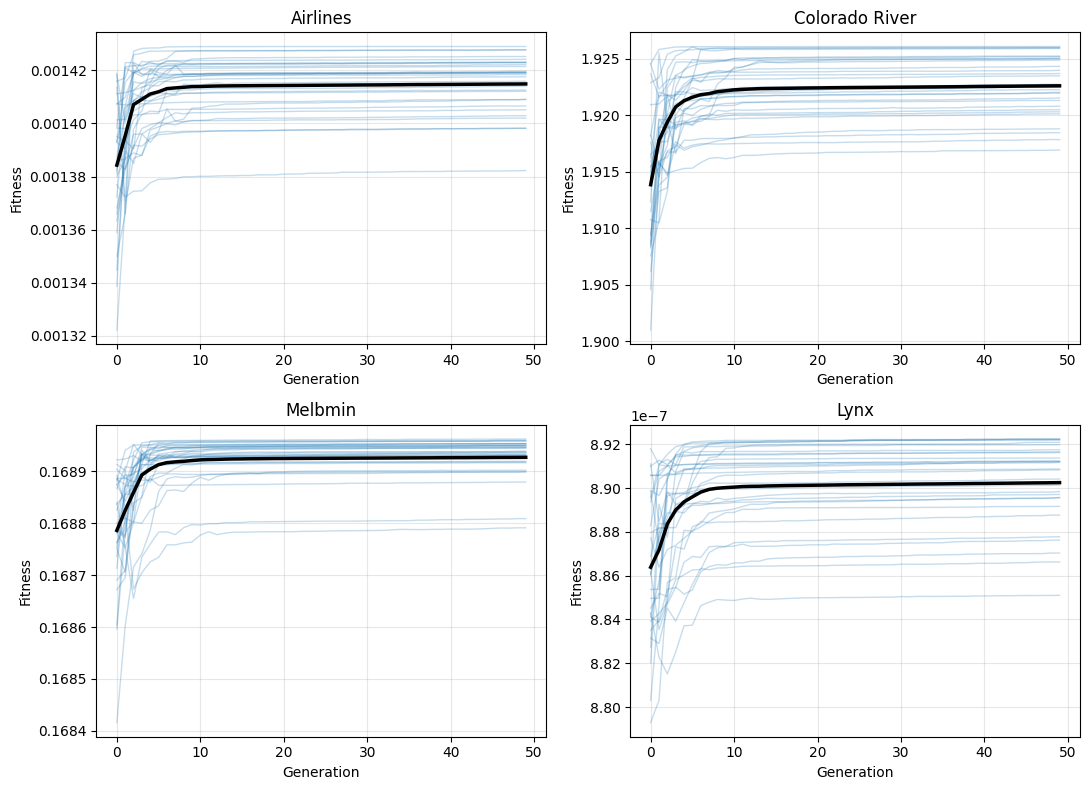

In [ ]:
datasets = [
    "airlines.txt",
    "coloradoRiver.txt",
    "melbmin.txt",
    "lynx.txt",
    "air_quality_rh",
    "appliances_energy"
]

titles = [
    "Airlines",
    "Colorado River",
    "Melbmin",
    "Lynx",
    "Air Quality",
    "Appliances"
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))

axes = axes.flatten()

for ax, dataset, title in zip(axes, datasets, titles):

    fitness_curves = np.array([
        run["Fitness_Curve"]
        for run in ga_runs
        if run["Dataset"] == dataset
    ])

    mean_curve = fitness_curves.mean(axis=0)

    # Todas as execuções
    for curve in fitness_curves:
        ax.plot(
            curve,
            color='tab:blue',
            alpha=0.25,
            linewidth=1
        )

    # Média
    ax.plot(
        mean_curve,
        color='black',
        linewidth=2.5,
        label='Average'
    )

    ax.set_title(title)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "ga_convergence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

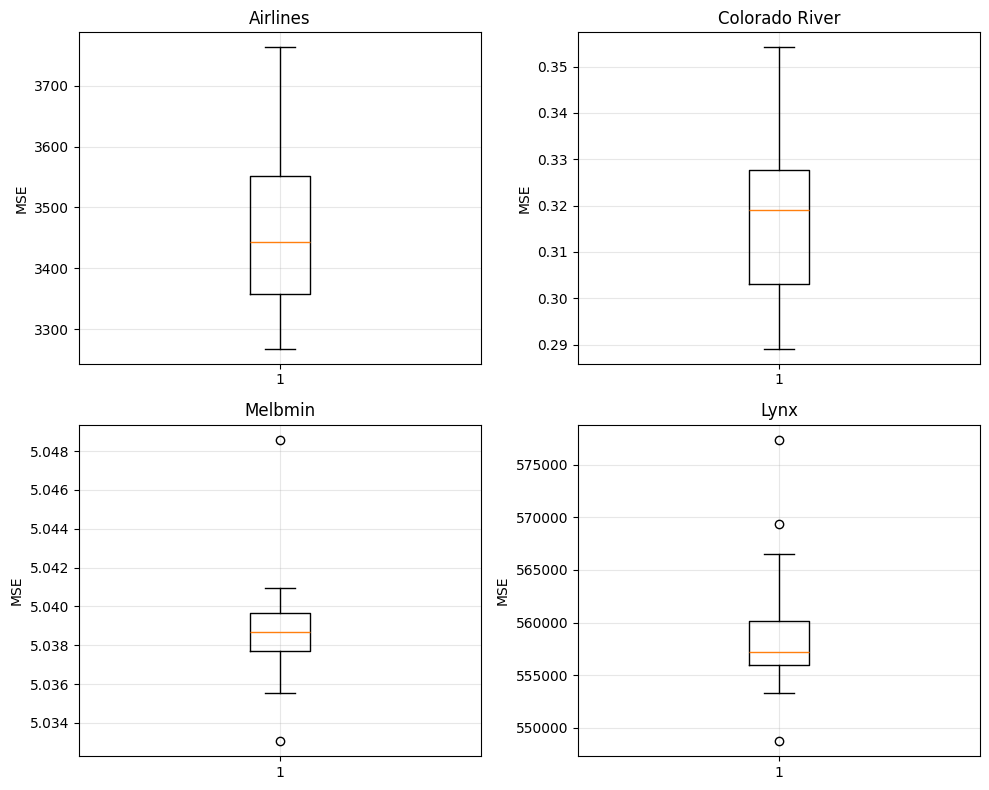

In [ ]:
datasets = [
    "airlines.txt",
    "coloradoRiver.txt",
    "melbmin.txt",
    "lynx.txt",
    "air_quality_rh",
    "appliances_energy"
]

titles = [
    "Airlines",
    "Colorado River",
    "Melbmin",
    "Lynx",
    "Air Quality",
    "Appliances"
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))

axes = axes.flatten()

for ax, dataset, title in zip(axes, datasets, titles):

    dados = df_ga[df_ga["Dataset"] == dataset]["MSE"]

    ax.boxplot(dados)

    ax.set_title(title)

    ax.set_ylabel("MSE")

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "ga_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Friedman

friedman_df = df_metrics.pivot(
    index='Dataset',
    columns='Model',
    values='MSE'

)

In [ ]:
friedman_df

Model,ADA,ELM,EMEAN,GA,KNN,MLP,SCN,SVR
Dataset,,,,,,,,
airlines.txt,2171.837052,14018.358953,3076.131205,3267.597447,27837.968332,3677.685524,8963.457483,15222.424587
coloradoRiver.txt,0.317598,0.262550,0.414042,0.293195,1.948353,0.297891,0.375189,0.315603
lynx.txt,626489.334807,568242.505240,587783.564614,557101.664606,1122578.521739,553054.971571,652678.137599,1615895.979524
melbmin.txt,5.171060,5.115625,5.055428,5.037248,5.712861,5.121536,5.142641,5.078260


In [ ]:
friedmanchisquare(

friedman_df['MLP'],
friedman_df['SCN'],
friedman_df['ELM'],
friedman_df['SVR'],
friedman_df['ADA'],
friedman_df['KNN'],
friedman_df['EMEAN'],
friedman_df['GA']
)

FriedmanchisquareResult(statistic=np.float64(15.0), pvalue=np.float64(0.03599940476342876))

In [ ]:
nemenyi = sp.posthoc_nemenyi_friedman(
    friedman_df.values
)
nemenyi.index = friedman_df.columns
nemenyi.columns = friedman_df.columns

In [ ]:
nemenyi

Model,ADA,ELM,EMEAN,GA,KNN,MLP,SCN,SVR
Model,,,,,,,,
ADA,1.000000,0.999135,0.999872,0.837013,0.567270,0.996387,0.996387,0.999135
ELM,0.999135,1.000000,1.000000,0.988970,0.215662,1.000000,0.899562,0.944413
EMEAN,0.999872,1.000000,1.000000,0.973060,0.288228,0.999992,0.944413,0.973060
GA,0.837013,0.988970,0.973060,1.000000,0.020314,0.996387,0.373136,0.467650
KNN,0.567270,0.215662,0.288228,0.020314,1.000000,0.156425,0.944413,0.899562
MLP,0.996387,1.000000,0.999992,0.996387,0.156425,1.000000,0.837013,0.899562
SCN,0.996387,0.899562,0.944413,0.373136,0.944413,0.837013,1.000000,1.000000
SVR,0.999135,0.944413,0.973060,0.467650,0.899562,0.899562,1.000000,1.000000


In [ ]:
ranks = friedman_df.rank(axis=1, ascending=True)
avg_ranks = ranks.mean(axis=0)
avg_ranks

,0
Model,
ADA,4.500000
ELM,3.500000
EMEAN,3.750000
GA,2.000000
KNN,7.750000
MLP,3.250000
SCN,5.750000
SVR,5.500000


{'markers': [<matplotlib.collections.PathCollection at 0x7d0f52ddcad0>,
 'elbows': [<matplotlib.lines.Line2D at 0x7d0f52d1a4e0>,
 'labels': [Text(1.99, -3, 'GA (2)'),
  Text(1.99, -4, 'MLP (3.2)'),
  Text(1.99, -5, 'ELM (3.5)'),
  Text(1.99, -6, 'EMEAN (3.8)'),
  Text(7.76, -3, '(7.8) KNN'),
  Text(7.76, -4, '(5.8) SCN'),
  Text(7.76, -5, '(5.5) SVR'),
  Text(7.76, -6, '(4.5) ADA')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x7d0f52d029c0>],
  [<matplotlib.lines.Line2D at 0x7d0f52d19f40>]]}

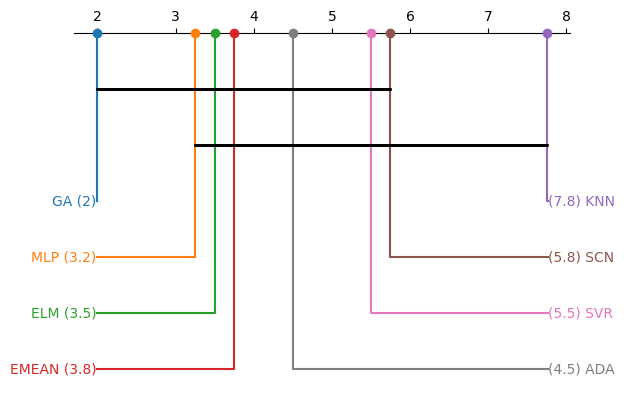

In [ ]:
from scikit_posthocs import critical_difference_diagram

critical_difference_diagram(
    avg_ranks,
    nemenyi
)

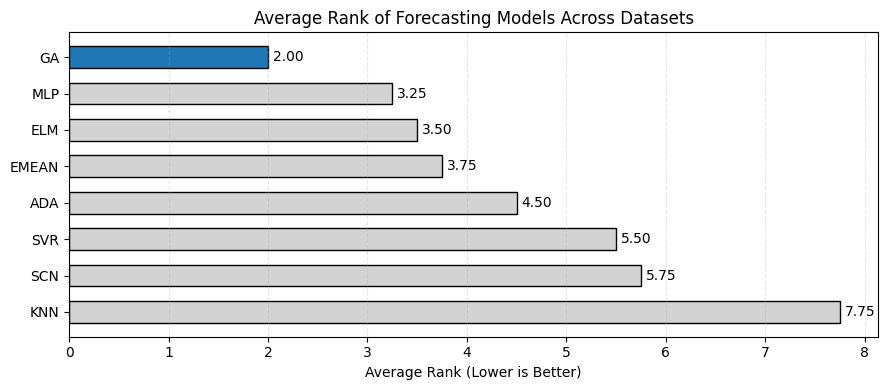

In [ ]:
avg_rank = (
    df_rank
    .groupby('Model')['Rank']
    .mean()
    .sort_values()
)

# Todos com Cinza
colors = ['lightgray'] * len(avg_rank)

# GA destaque
ga_idx = avg_rank.index.get_loc('GA')
colors[ga_idx] = 'tab:blue'

fig, ax = plt.subplots(figsize=(9,4))

bars = ax.barh(
    avg_rank.index,
    avg_rank.values,
    color=colors,
    edgecolor='black',
    height=0.6
)

ax.invert_yaxis()

ax.set_xlabel("Average Rank (Lower is Better)")
ax.set_title("Average Rank of Forecasting Models Across Datasets")

ax.grid(axis='x', linestyle='--', alpha=0.3)

for bar in bars:
    ax.text(
        bar.get_width()+0.05,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va='center'
    )

plt.tight_layout()
plt.show()

In [1]:
# Quais modelos foram escolhidos em cada BASE
selected = []

for run in ga_runs:

    selected.append({

        "Dataset": run["Dataset"],

        "Selected": ", ".join(run["Selected_Models"])
    })

df_selected = (
    pd.DataFrame(selected)
    .drop_duplicates()
)
df_selected

NameError: name 'ga_runs' is not defined

In [ ]:


counter = Counter()

for run in ga_runs:

    counter.update(run["Selected_Models"])

counter

Counter({'ADA': 60, 'ELM': 90, 'SCN': 120, 'MLP': 90, 'KNN': 60, 'SVR': 60})